In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
df= pd.read_csv("datasets/bundataset.csv")
# print(df.head())
df=df.drop("id",axis=1)
df.head()

,bun_size,nearby_pigeons_count,time_of_day,feeding_spot_popularity,distance_to_pigeons_m,is_raining,crumbs_on_ground,crowd_density,human_distance_m,noise_level,will_eat_bun
0,2.117397,5,11,5.183150,7.780918,0,5.472407,5,1.074004,10,0
1,1.850617,5,17,4.595100,3.644349,1,2.290217,2,3.159703,1,1
2,1.575189,1,9,1.810567,2.309359,0,3.719027,1,3.762946,1,0
3,0.790015,8,12,8.548308,5.182641,1,5.983987,10,1.948632,5,0
4,1.003298,4,19,4.046106,2.514642,0,3.413828,0,2.363299,10,1


In [4]:
df.columns

Index(['bun_size', 'nearby_pigeons_count', 'time_of_day',
       'feeding_spot_popularity', 'distance_to_pigeons_m', 'is_raining',
       'crumbs_on_ground', 'crowd_density', 'human_distance_m', 'noise_level',
       'will_eat_bun'],
      dtype='object')

In [5]:
# for i in df.columns:
#     print(i, typedf[i])
df.dtypes

bun_size                   float64
nearby_pigeons_count         int64
time_of_day                  int64
feeding_spot_popularity    float64
distance_to_pigeons_m      float64
is_raining                   int64
crumbs_on_ground           float64
crowd_density                int64
human_distance_m           float64
noise_level                  int64
will_eat_bun                 int64
dtype: object

In [6]:
df["will_eat_bun"].value_counts()

will_eat_bun
1    1203
0     797
Name: count, dtype: int64

In [7]:
categorical=[2,5,10]
binarize_categorical=[1 if i in categorical else 0 for i in range(11)]
# for i in range(11):
#     if i in categorical:
#         binarize_categorical.append(1)
#     else:0
print(binarize_categorical)

df["will_eat_bun"] = df["will_eat_bun"].astype('category')
df["is_raining"] = df["is_raining"].astype('category')
df["time_of_day"] = df["time_of_day"].astype('category')

[0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1]


In [8]:
df.dtypes

bun_size                    float64
nearby_pigeons_count          int64
time_of_day                category
feeding_spot_popularity     float64
distance_to_pigeons_m       float64
is_raining                 category
crumbs_on_ground            float64
crowd_density                 int64
human_distance_m            float64
noise_level                   int64
will_eat_bun               category
dtype: object

In [9]:
df.head()

,bun_size,nearby_pigeons_count,time_of_day,feeding_spot_popularity,distance_to_pigeons_m,is_raining,crumbs_on_ground,crowd_density,human_distance_m,noise_level,will_eat_bun
0,2.117397,5,11,5.183150,7.780918,0,5.472407,5,1.074004,10,0
1,1.850617,5,17,4.595100,3.644349,1,2.290217,2,3.159703,1,1
2,1.575189,1,9,1.810567,2.309359,0,3.719027,1,3.762946,1,0
3,0.790015,8,12,8.548308,5.182641,1,5.983987,10,1.948632,5,0
4,1.003298,4,19,4.046106,2.514642,0,3.413828,0,2.363299,10,1


In [10]:
for i in zip(df.dtypes):
    print(i)

(dtype('float64'),)
(dtype('int64'),)
(CategoricalDtype(categories=[8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20], ordered=False, categories_dtype=int64),)
(dtype('float64'),)
(dtype('float64'),)
(CategoricalDtype(categories=[0, 1], ordered=False, categories_dtype=int64),)
(dtype('float64'),)
(dtype('int64'),)
(dtype('float64'),)
(dtype('int64'),)
(CategoricalDtype(categories=[0, 1], ordered=False, categories_dtype=int64),)


In [11]:
# sns.heatmap(, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
corrmatrix=df.corr(numeric_only=True)
corrmatrix

,bun_size,nearby_pigeons_count,feeding_spot_popularity,distance_to_pigeons_m,crumbs_on_ground,crowd_density,human_distance_m,noise_level
bun_size,1.000000,0.005345,-0.002454,0.009005,-0.024772,-0.008896,-0.000258,-0.022802
nearby_pigeons_count,0.005345,1.000000,0.023118,-0.001373,0.003143,0.033653,-0.007726,0.002717
feeding_spot_popularity,-0.002454,0.023118,1.000000,-0.000727,-0.008898,0.041322,0.002375,-0.029120
distance_to_pigeons_m,0.009005,-0.001373,-0.000727,1.000000,-0.007258,0.026872,0.048005,0.000309
crumbs_on_ground,-0.024772,0.003143,-0.008898,-0.007258,1.000000,0.040824,-0.038271,-0.003866
crowd_density,-0.008896,0.033653,0.041322,0.026872,0.040824,1.000000,0.002557,0.012328
human_distance_m,-0.000258,-0.007726,0.002375,0.048005,-0.038271,0.002557,1.000000,0.018694
noise_level,-0.022802,0.002717,-0.029120,0.000309,-0.003866,0.012328,0.018694,1.000000


<Axes: >

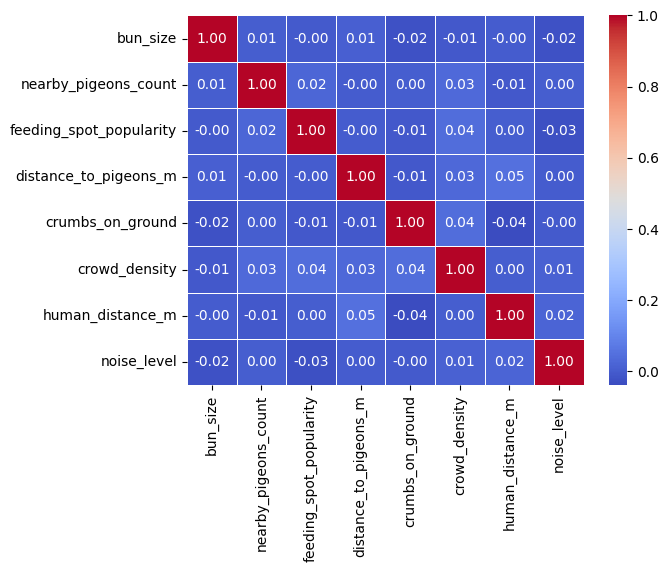

In [12]:
sns.heatmap(corrmatrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
# poor correlation


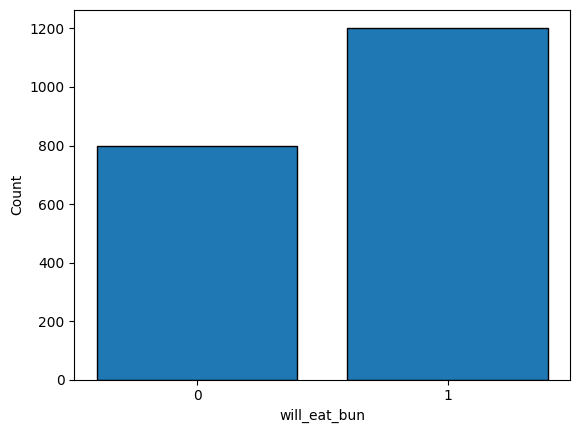

In [13]:
counts = df["will_eat_bun"].value_counts().sort_index()

plt.bar(counts.index, counts.values, edgecolor='black')
plt.xticks(counts.index) # imp
plt.xlabel("will_eat_bun")
plt.ylabel("Count")
plt.show()
# imbalance class


In [14]:
# for i,j in df.items:
# for i in df:
#     # print(i)
#     # print(df[i].dtype)
# df[df[""]]
# for i,j in df.items:
#     if(df[i].dtype!="category"):
#         df[i].unique[0]

In [15]:
# plt.violinplot(df["bun_size"])
# plt.violinplot(x=df['will_eat_bun'],y=df["bun_size"])

In [16]:
# import matplotlib.pyplot as plt
# import numpy as np

# # Make data
# np.random.seed(0)
# D = np.random.normal((3, 5, 4.5), (1.00, 0.75, 1.25), (100, 3))

# # print(D)
# # Plot
# fig, ax = plt.subplots()
# vp = ax.violinplot(D)
# plt.show()


In [17]:
non_categorical_cols = df.select_dtypes(include=['number']).columns
non_categorical_cols

Index(['bun_size', 'nearby_pigeons_count', 'feeding_spot_popularity',
       'distance_to_pigeons_m', 'crumbs_on_ground', 'crowd_density',
       'human_distance_m', 'noise_level'],
      dtype='object')

In [18]:
# print(len(categorical_cols))

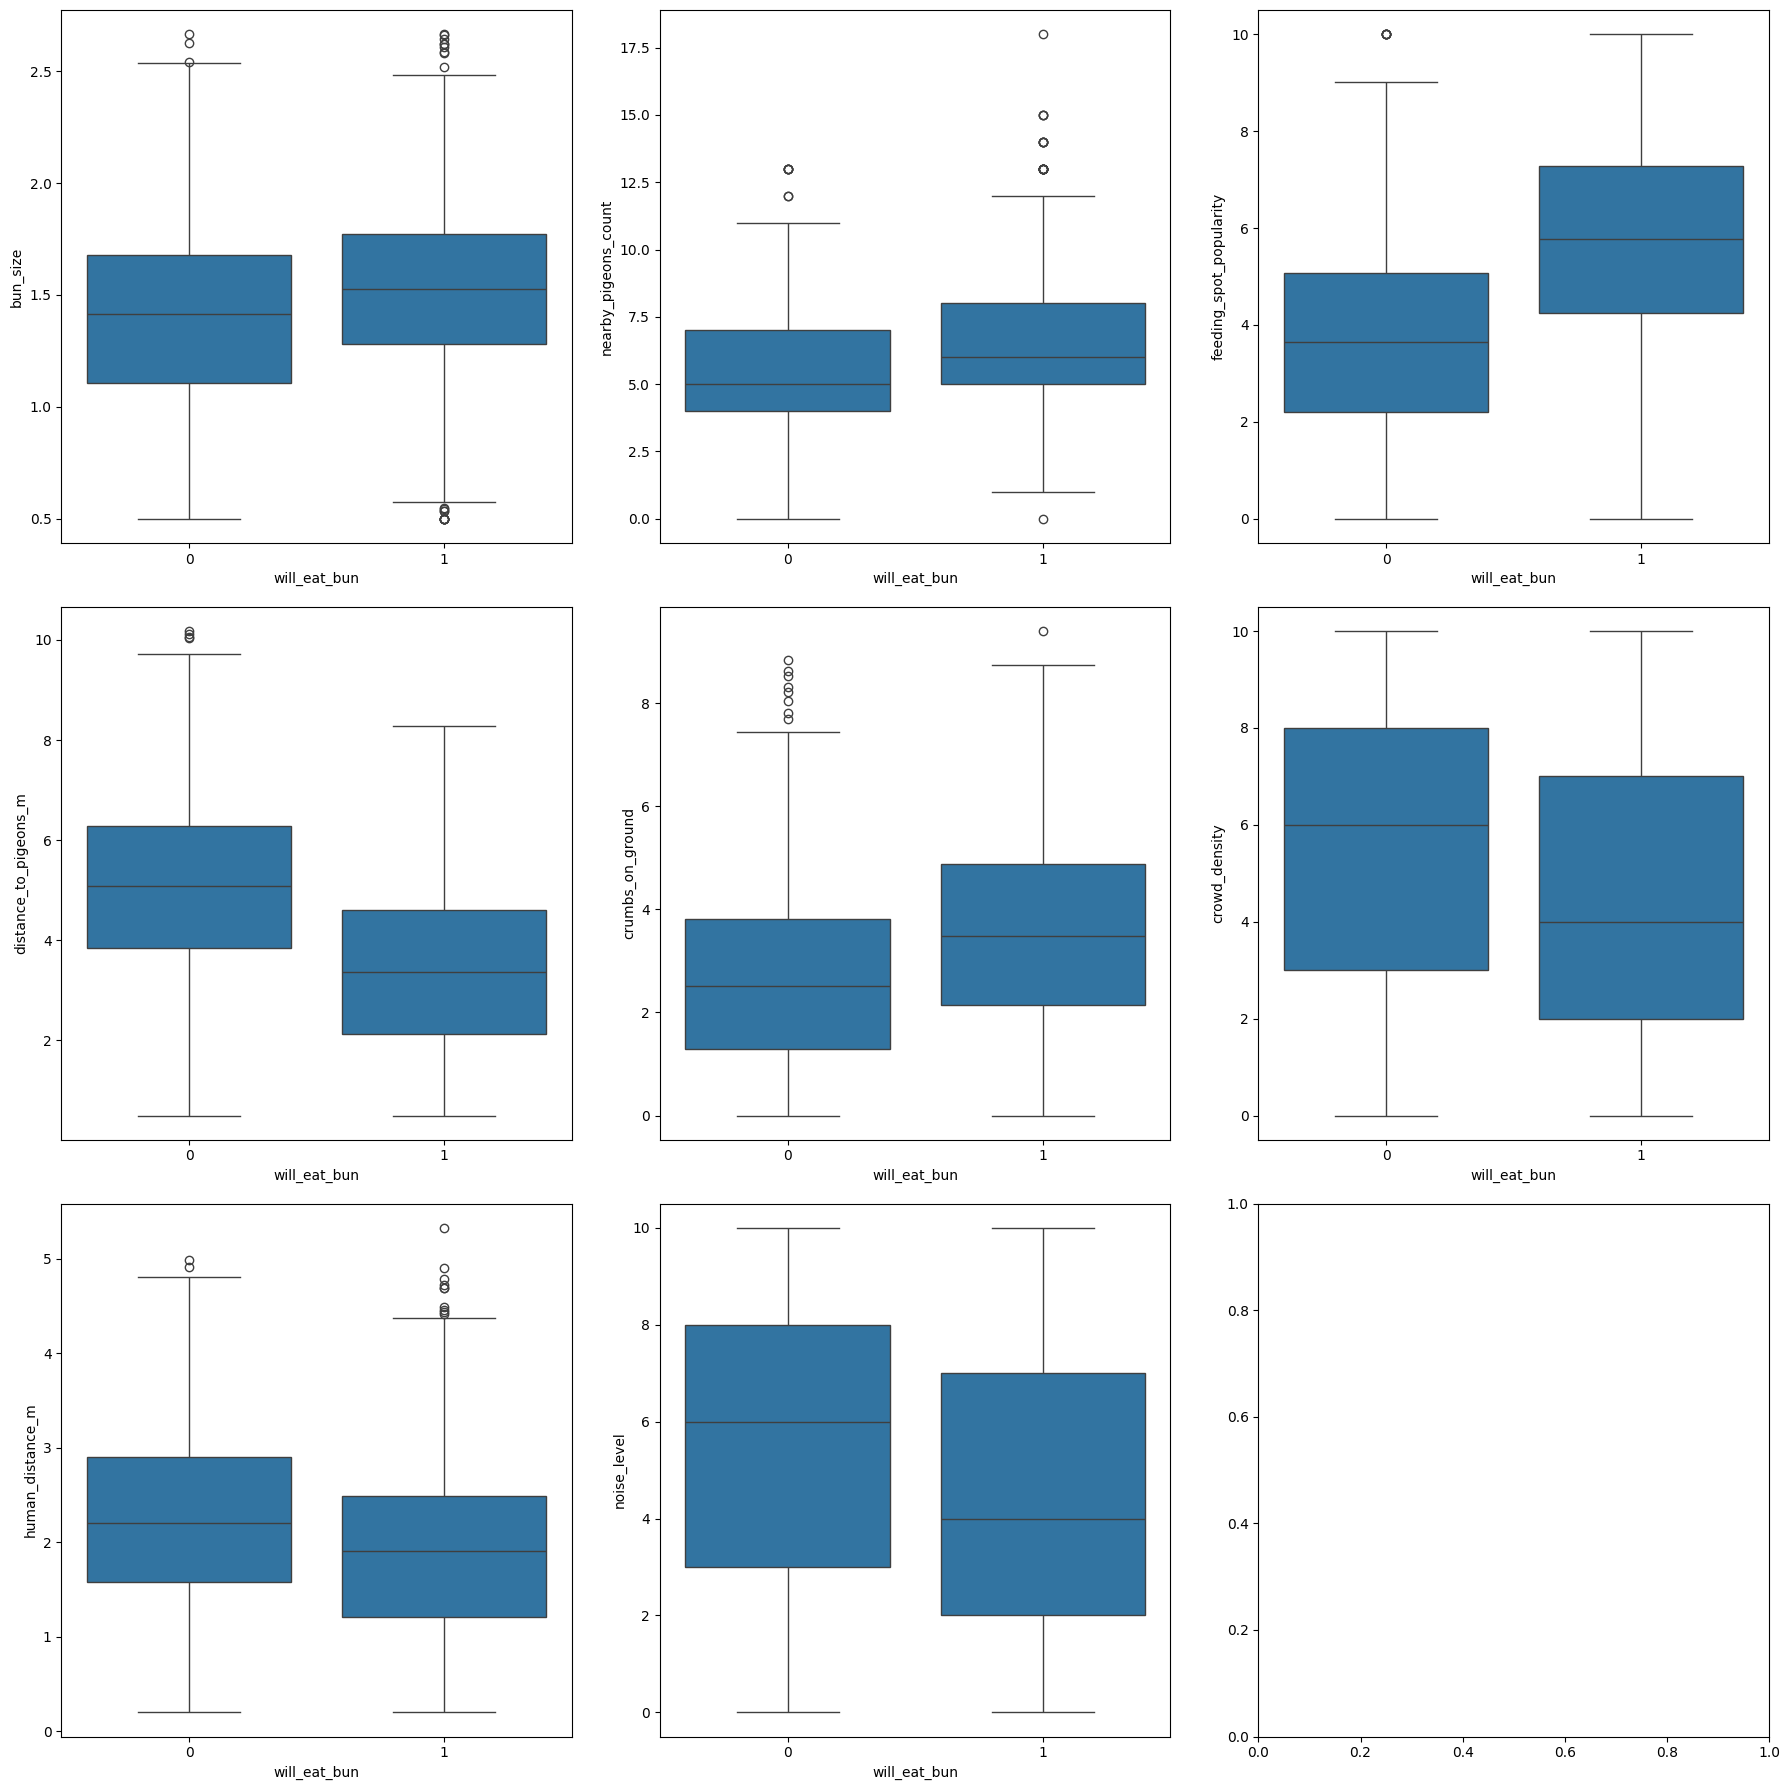

In [19]:
import math

total_plots = len(non_categorical_cols) 
cols = 3
rows = math.ceil(total_plots / cols)

fig_width = cols * 6
fig_height = rows * 6

fig, axes = plt.subplots(
    nrows=rows,
    ncols=cols,
    figsize=(fig_width, fig_height),
    # constrained_layout=True
)
row,col=0,0
for i in df.columns:
    if df[i].dtype!="category":
        sns.boxplot(ax=axes[row,col],x=df['will_eat_bun'],y=df[i])
        col=col+1
        if(col==3):
            row+=1
        col=(col)%cols

plt.tight_layout(w_pad=2)
plt.show()

<Axes: xlabel='time_of_day', ylabel='bun_size'>

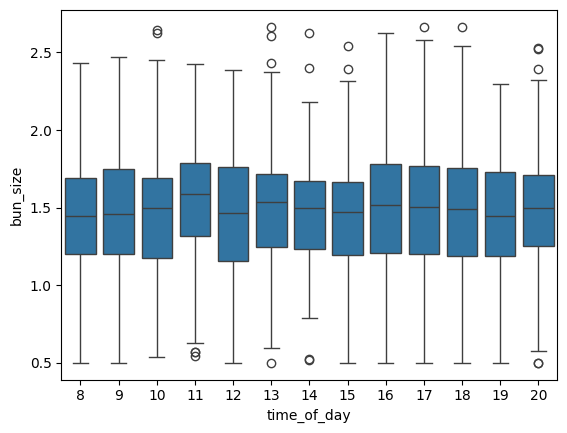

In [20]:
sns.boxplot(x=df['time_of_day'],y=df["bun_size"])
# this will help me tell quality of bun at what time 


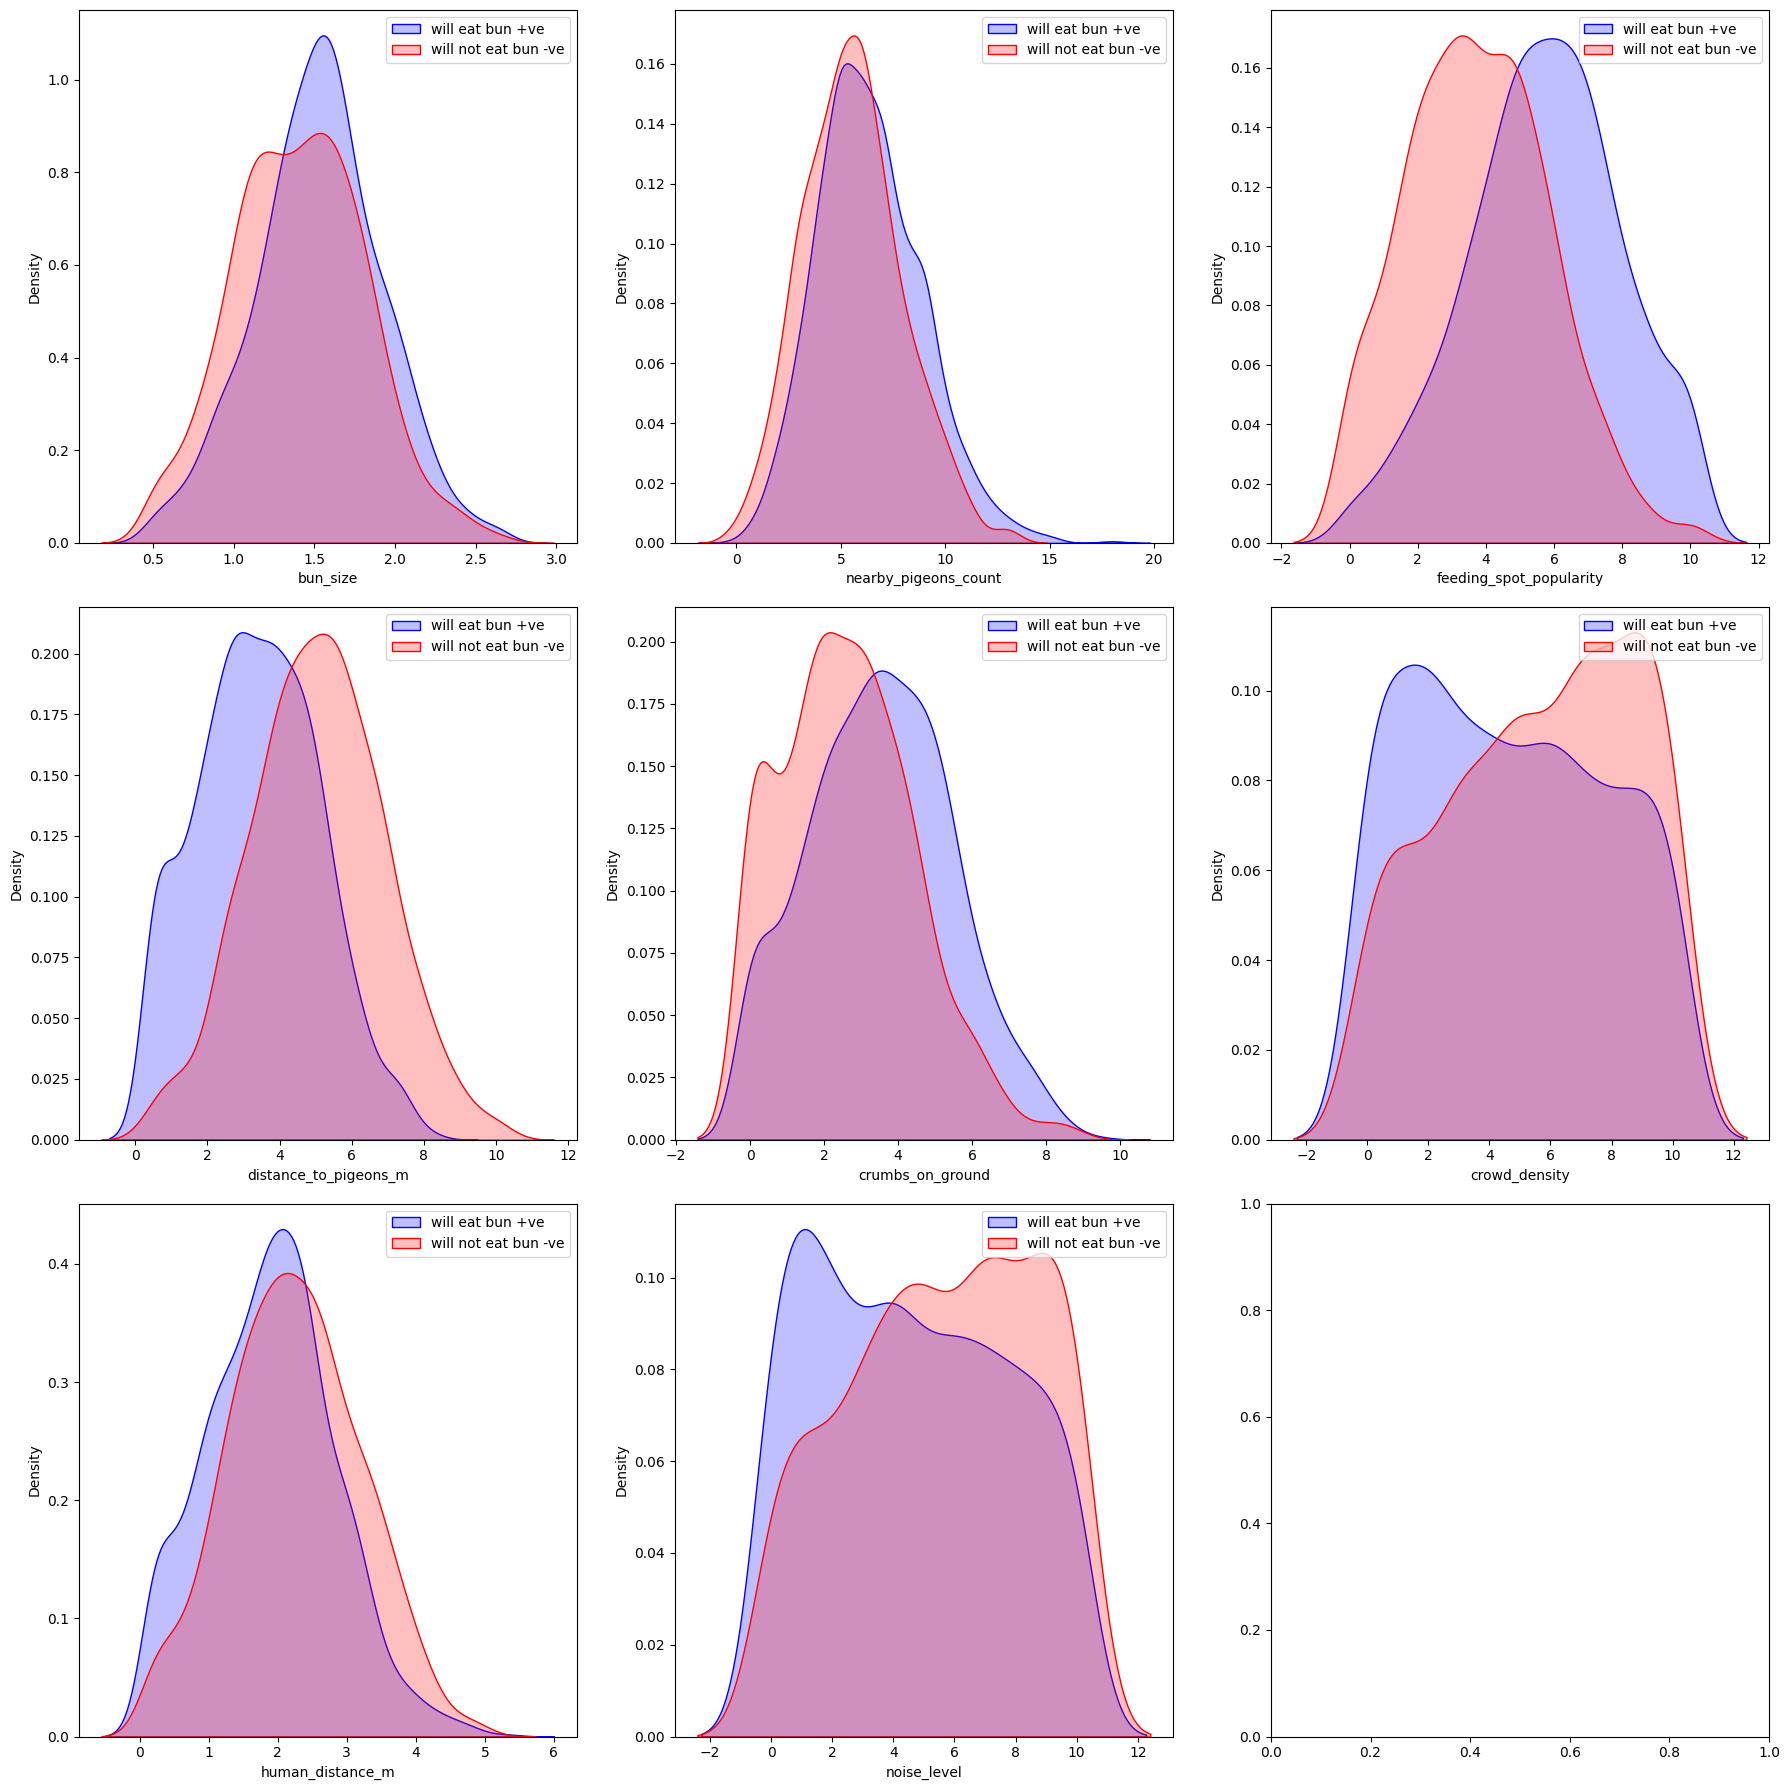

In [21]:

total_plots = len(non_categorical_cols) 
cols = 3
rows = math.ceil(total_plots / cols)

fig_width = cols * 6
fig_height = rows * 6

fig, axes = plt.subplots(
    nrows=rows,
    ncols=cols,
    figsize=(fig_width, fig_height),
    # constrained_layout=True
)
row,col=0,0

for i in df.columns:
    if df[i].dtype!="category":
        
        sns.kdeplot(
            df[df["will_eat_bun"]==1][i],
            color='blue', label='will eat bun +ve',
            ax=axes[row,col],
            fill=True
            )
        
        sns.kdeplot(
            df[df["will_eat_bun"]==0][i],
            color='red', 
            label='will not eat bun -ve',
            ax=axes[row,col],
            fill=True
            )
        
        axes[row, col].legend()
        col=col+1
        if(col==3):
            row+=1
        col=(col)%cols

plt.tight_layout(w_pad=2)
plt.show()





In [22]:
df[df['will_eat_bun']==1]["bun_size"]


1       1.850617
4       1.003298
6       1.454316
7       2.348457
8       1.449996
          ...   
1994    2.130271
1995    0.706343
1996    1.286619
1997    1.540579
1998    2.087975
Name: bun_size, Length: 1203, dtype: float64

In [23]:
df["time_of_day"] = df["time_of_day"].astype('int')

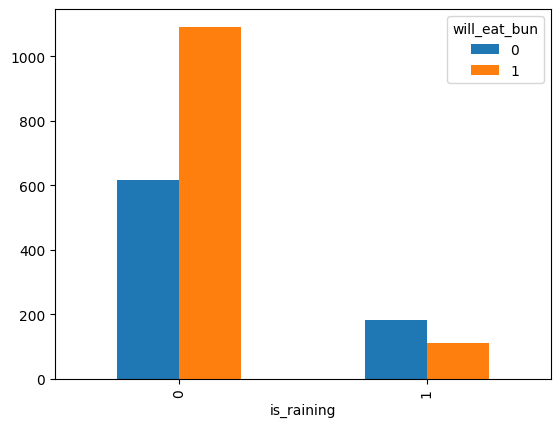

In [24]:
crosstb = pd.crosstab(df["is_raining"], df["will_eat_bun"])
crosstb
pl = crosstb.plot(kind="bar")


In [25]:
bins = [8, 12, 16, 20]
labels = ["8-12", "12-16", "16-20"]

df2=df
df2["time_bin"] = pd.cut(
    df2["time_of_day"],
    bins=bins,
    labels=labels,
    right=False 
)
df2

,bun_size,nearby_pigeons_count,time_of_day,feeding_spot_popularity,distance_to_pigeons_m,is_raining,crumbs_on_ground,crowd_density,human_distance_m,noise_level,will_eat_bun,time_bin
0,2.117397,5,11,5.183150,7.780918,0,5.472407,5,1.074004,10,0,8-12
1,1.850617,5,17,4.595100,3.644349,1,2.290217,2,3.159703,1,1,16-20
2,1.575189,1,9,1.810567,2.309359,0,3.719027,1,3.762946,1,0,8-12
3,0.790015,8,12,8.548308,5.182641,1,5.983987,10,1.948632,5,0,12-16
4,1.003298,4,19,4.046106,2.514642,0,3.413828,0,2.363299,10,1,16-20
...,...,...,...,...,...,...,...,...,...,...,...,...
1995,0.706343,4,15,9.113976,4.063131,0,1.306186,1,2.565787,0,1,12-16
1996,1.286619,8,12,5.245126,5.113233,0,7.382402,4,3.244621,5,1,12-16
1997,1.540579,8,11,2.989479,2.615970,1,5.255059,5,2.405632,2,1,8-12
1998,2.087975,8,17,4.983706,3.508900,0,7.405171,7,1.770812,1,1,16-20


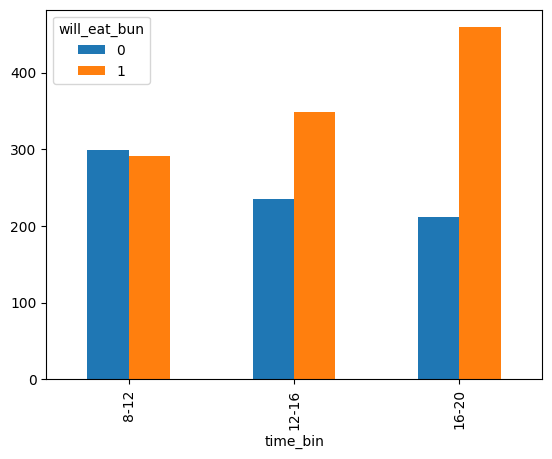

In [26]:
crstb2=pd.crosstab(df2["time_bin"],df2["will_eat_bun"])
pl = crstb2.plot(kind="bar")

# extra 2 / binning in hist and KDE

<Axes: xlabel='bun_size', ylabel='Count'>

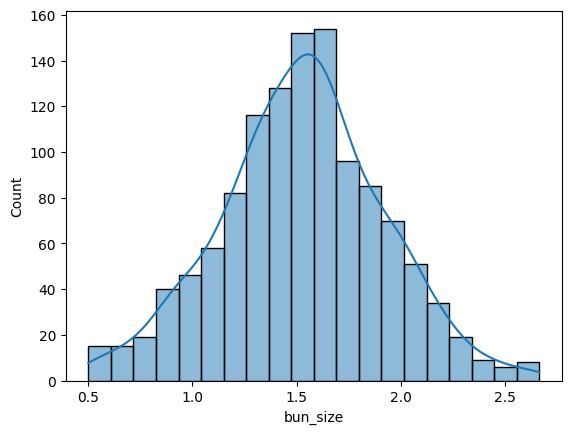

In [27]:
sns.histplot(df[df["will_eat_bun"]==1]["bun_size"],bins=20,kde=True)
# here imabalance classes could be an issue if we plot for yes and no class labels 
# but in kde directly this issue won't arrise as it just lies in 0 to 1 range of y axis

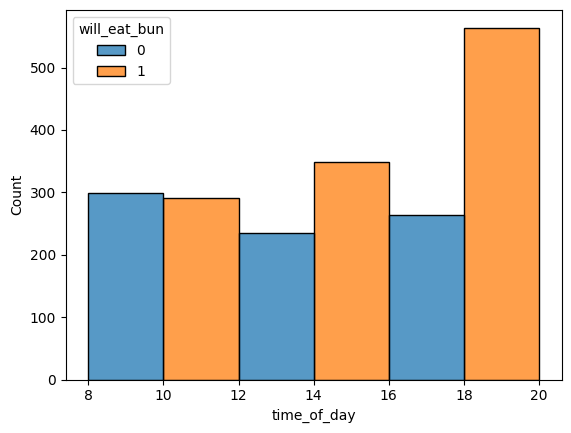

<Axes: xlabel='time_of_day', ylabel='Count'>

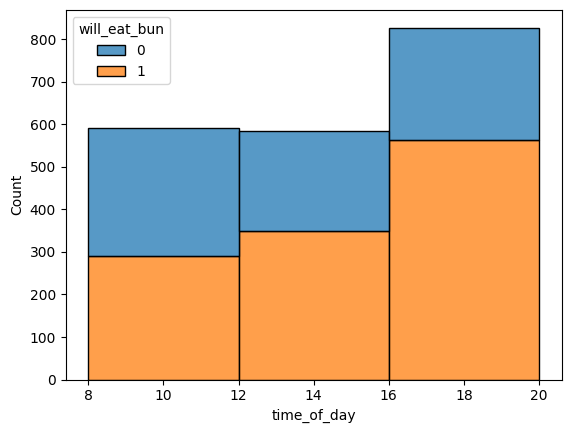

In [28]:
sns.histplot(  # IT REQUIRES COLUMN TO BE NUMERIC
    data=df,
    x="time_of_day",
    hue="will_eat_bun",    
    bins=[8, 12, 16, 20], 
    multiple="dodge" 
)
plt.show()
sns.histplot(  # IT REQUIRES COLUMN TO BE NUMERIC
    data=df,
    x="time_of_day",
    hue="will_eat_bun",    
    bins=[8, 12, 16, 20], 
    multiple="stack" 
)

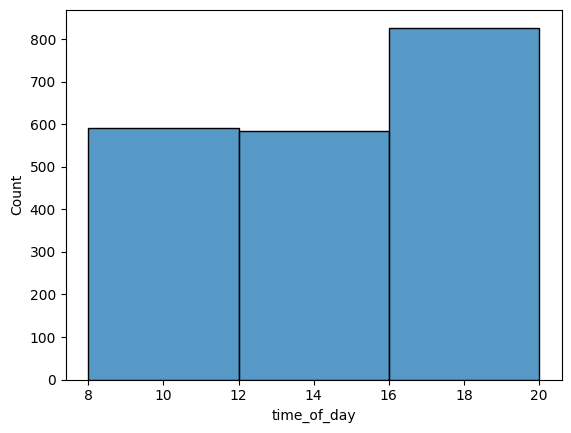

In [29]:
sns.histplot(  # IT REQUIRES COLUMN TO BE NUMERIC
    data=df,
    x="time_of_day",
    bins=[8, 12, 16, 20], 
    multiple="dodge" 
)
plt.show()

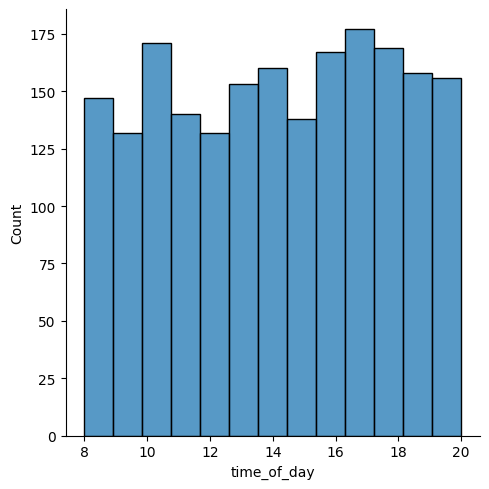

In [30]:
sns.displot(df["time_of_day"],)

# after EDA


In [50]:
df.dtypes

bun_size                    float64
nearby_pigeons_count          int64
time_of_day                   int64
feeding_spot_popularity     float64
distance_to_pigeons_m       float64
is_raining                 category
crumbs_on_ground            float64
crowd_density                 int64
human_distance_m            float64
noise_level                   int64
will_eat_bun               category
dtype: object

In [ ]:
df=df.drop("time_bin",axis=1)

In [55]:
X = df.drop(columns=['will_eat_bun'])

y = df['will_eat_bun']
X.head()

,bun_size,nearby_pigeons_count,time_of_day,feeding_spot_popularity,distance_to_pigeons_m,is_raining,crumbs_on_ground,crowd_density,human_distance_m,noise_level
0,2.117397,5,11,5.183150,7.780918,0,5.472407,5,1.074004,10
1,1.850617,5,17,4.595100,3.644349,1,2.290217,2,3.159703,1
2,1.575189,1,9,1.810567,2.309359,0,3.719027,1,3.762946,1
3,0.790015,8,12,8.548308,5.182641,1,5.983987,10,1.948632,5
4,1.003298,4,19,4.046106,2.514642,0,3.413828,0,2.363299,10


In [73]:
y.value_counts()

will_eat_bun
1    1203
0     797
Name: count, dtype: int64

In [65]:
from imblearn.under_sampling import RandomUnderSampler
rus = RandomUnderSampler(sampling_strategy='majority')
X_resampled_down, y_resampled_down = rus.fit_resample(X, y)

In [ ]:
y_resampled_down.value_counts()

will_eat_bun
0    797
1    797
Name: count, dtype: int64

In [75]:
numerical_cols = X_resampled_down.select_dtypes(include=['int64', 'float64']).columns
len(numerical_cols)

9

In [77]:
catcol=[]
for i in X.columns:
    if X[i].dtype=="category":
        catcol.append(i)
catcol

['is_raining']

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(X_resampled_down, y_resampled_down,test_size=0.2,random_state=42,stratify=y_resampled_down)

In [ ]:
# METHOD 1 manual method
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_num = scaler.fit_transform(x_train[numerical_cols])
x_test_num  = scaler.transform(x_test[numerical_cols])

x_train_num = pd.DataFrame(
    x_train_num,
    columns=numerical_cols,
    index=x_train.index
)

x_test_num = pd.DataFrame(
    x_test_num,
    columns=numerical_cols,
    index=x_test.index
)
x_train_std = pd.concat([x_train_num, x_train[catcol]], axis=1)
x_test_std  = pd.concat([x_test_num,  x_test[catcol]], axis=1)



In [ ]:
#Method 2 better way
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

preprocessor = ColumnTransformer(
    [
        ('num', StandardScaler(), numerical_cols),
        ('cat', 'passthrough', catcol)
    ]
    
)

x_train_std = preprocessor.fit_transform(x_train)
x_test_std  = preprocessor.transform(x_test)


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression

skf=StratifiedKFold(n_splits=5)
skf.get_n_splits(x_test_std,y_train)